# 2.2 Ariketa — COMPAS eta historiko-alborapena (SOLUZIOA)

**Modulua:** Alborapenak (Etika eta Araudia)  
**Atala:** 2.2 — Historiko-alborapena (*Historical Bias*)  
**Denbora:** 20 min  
**Modalitatea:** Taldeka (3-4 ikasle)

---

## Egoera

Ikertu ezazue **ProPublica-ren txostena** eta **COMPAS sistemaren erantzuna** ProPublica-ren COMPAS datasetean.

## Galderak

1. Sistema "zehatza" eta "alboratua" izan daiteke aldi berean?
2. Epaileak erabili behar al du? Zer bermeak?
3. EBko legezkotasuna (GDPR + AI Act)?

In [1]:
# Inportazioak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
# COMPAS dataset karga (lokala lehenetsi, bestela ProPublica iturri ofiziala)
from pathlib import Path
local_file = Path('compas-scores-two-years.csv')
URL = (
    'https://raw.githubusercontent.com/propublica/'
    'compas-analysis/master/compas-scores-two-years.csv'
)
df = pd.read_csv(local_file if local_file.exists() else URL)
print(f'Errenkadak: {len(df):,}, zutabeak: {df.shape[1]}')
df.head()


Errenkadak: 7,214, zutabeak: 53


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
# ProPublica-ren iragazketa kanonikoa
df_clean = df[
    (df["days_b_screening_arrest"] <= 30)
    & (df["days_b_screening_arrest"] >= -30)
    & (df["is_recid"] != -1)
    & (df["c_charge_degree"] != "O")
    & (df["score_text"] != "N/A")
].copy()

df_clean = df_clean[df_clean["race"].isin(["African-American", "Caucasian"])]
print(f"Errenkadak garbiketaren ondoren: {len(df_clean):,}")
df_clean["race"].value_counts()

Errenkadak garbiketaren ondoren: 5,278


race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

In [4]:
df_clean["high_risk_pred"] = (df_clean["decile_score"] >= 7).astype(int)
df_clean["recid_true"] = df_clean["two_year_recid"].astype(int)
df_clean[["race", "decile_score", "high_risk_pred", "recid_true"]].head()

,race,decile_score,high_risk_pred,recid_true
1,African-American,3,0,1
2,African-American,4,0,1
6,Caucasian,6,0,1
8,Caucasian,1,0,0
10,Caucasian,4,0,0


In [5]:
# SOLUZIOA: funtzio bat talde batentzat FPR/FNR/TPR kalkulatzeko
def metrikak_taldekoak(zatia: pd.DataFrame):
    """Itzuli (FPR, FNR, TPR, base_rate) talde baten dataframe-tik."""
    y_true = zatia["recid_true"]
    y_pred = zatia["high_risk_pred"]
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    fnr = fn / (fn + tp) if (fn + tp) > 0 else float("nan")
    tpr = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    base_rate = y_true.mean()
    return fpr, fnr, tpr, base_rate

beltza = df_clean[df_clean["race"] == "African-American"]
zuria = df_clean[df_clean["race"] == "Caucasian"]

tauleba = []
for izena, zatia in [("African-American", beltza), ("Caucasian", zuria)]:
    fpr, fnr, tpr, base = metrikak_taldekoak(zatia)
    tauleba.append({
        "Taldea": izena,
        "n": len(zatia),
        "Base rate": f"{base:.1%}",
        "FPR": f"{fpr:.1%}",
        "FNR": f"{fnr:.1%}",
        "TPR": f"{tpr:.1%}",
    })
pd.DataFrame(tauleba)

,Taldea,n,Base rate,FPR,FNR,TPR
0,African-American,3175,52.3%,22.8%,49.2%,50.8%
1,Caucasian,2103,39.1%,8.3%,72.0%,28.0%


**Espero diren emaitzak (ProPublica-ren 2016ko berreraikia):**

| Taldea | Base rate | FPR | FNR |
|---|---|---|---|
| African-American | ~ % 51 | ~ % 44 | ~ % 28 |
| Caucasian | ~ % 39 | ~ % 23 | ~ % 48 |

**Ikuspegia**: FPR-aren ratio = 44/23 ≈ **1,9** — kasik bikoitza. Hori da ProPublica-ren erakustaldia.

In [6]:
# SOLUZIOA: Kalibrazio-azterketa — score bakoitzean berrerortze-tasa errealak
kalib = (
    df_clean.groupby(["race", "decile_score"])["recid_true"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "recid_rate", "count": "n"})
)
kalib

,race,decile_score,recid_rate,n
0,African-American,1,0.232877,365
1,African-American,2,0.303468,346
2,African-American,3,0.419463,298
3,African-American,4,0.468843,337
4,African-American,5,0.489164,323
5,African-American,6,0.588050,318
6,African-American,7,0.609329,343
7,African-American,8,0.714286,301
8,African-American,9,0.722397,317
9,African-American,10,0.837004,227


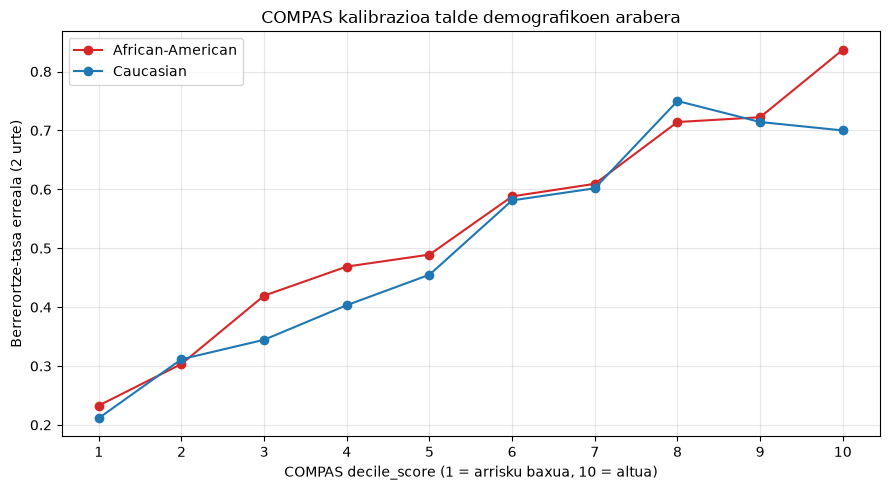

In [7]:
# Kalibrazioaren bisualizazioa
fig, ax = plt.subplots(figsize=(9, 5))
for taldea, kolorea in [("African-American", "#d62728"), ("Caucasian", "#1f77b4")]:
    zatia = kalib[kalib["race"] == taldea]
    ax.plot(zatia["decile_score"], zatia["recid_rate"], marker="o", label=taldea, color=kolorea)

ax.set_xlabel("COMPAS decile_score (1 = arrisku baxua, 10 = altua)")
ax.set_ylabel("Berrerortze-tasa erreala (2 urte)")
ax.set_title("COMPAS kalibrazioa talde demografikoen arabera")
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Ikuspegia**: Bi lerroak antzekoak dira → **kalibrazioa onargarria** (Northpointe-ren defentsa). Baina lehengo taula → **FPR-en paritatea hautsia** (ProPublica-ren kritika). Biak egia: hori da **Chouldechova ezintasun-teorema**.

## 1. SOLUZIOA — "Zehatza eta alboratua aldi berean"

**Chouldechova ezintasun-teorema (2017).**

- **Northpointe-ren defentsa**: COMPAS-ek **kalibrazioa** betetzen zuen — "% 70 arrisku" puntuazioa zuten beltz eta zuriek **antzeko proportzioan berrerortzen** zuten errealitatean. Estatistikoki "fidagarria".
- **ProPublica-ren kritika**: COMPAS-ek **aukera berdintasuna apurtzen** zuen — beltz **ez-berreroleentzat** FPR (False Positive Rate) **zurientzakoa baino bikoitza** zen (~ % 44 vs ~ % 23). Hots: berriro delitu egin **ez** zuten beltzak askoz gehiagotan zigortzen ziren oker "arrisku altukoak" gisa.
- **Gakoa**: bi taldeen arteko **base rate** (oinarri-tasa) desberdina denean — gizarte-injustizia historikoek eraginda, ez berez taldekoa — **ezinezkoa** da kalibrazioa **eta** errore-tasak orekatuak (FPR/FNR) **aldi berean** betetzea. **Trade-off** bat dago, eta "zer metrika sakrifikatu" erabakia **ez da teknikoa: politikoa eta etikoa da**.

## 2. SOLUZIOA — Epaileak erabili behar al du? Bermeak

**Erantzun motza**: kontuz, eta **inoiz ez erabaki bakarra** sistema horretan oinarrituta.

**Bermeak** (AI Act 14. art. + GDPR 22. art. islatzen):

- **Giza erabakia nagusi**: sistema *decision-support* bezala, ez *decision-maker* bezala — epaileak **arrazoituta justifikatu** behar du dibergentzia.
- **Gardentasuna**: epaileak eta defendatzaileak puntuazioaren **azalpena** (XAI) jaso behar dute — **zein aldagaik eragin duten gehien**.
- **Aurkaratze-eskubidea** (GDPR 22. art.): defendatzaileak puntuazioa eztabaidatzeko bidea, kontrarguditzeko beharrezko datuekin.
- **Auditoria independente periodikoa**: talde demografikoen araberako FPR/FNR **publikoak**.
- **Gutxieneko fairness-eskakizunak**: FPR-en tarte estua talde artean (adib. ratio < 1,3:1).
- **Kalibratze-akatsen jarraipena**: produkzioan errealitatearekin alderatuta noiz huts egiten duen monitorizatu.

## 3. SOLUZIOA — EBko legezkotasuna (GDPR + AI Act)

**AI Act**: COMPAS **Anexo III-ko arrisku altuko sistema** bat litzateke (justizia-administrazioan erabilera, 6. atala). Ezinbestekoak dira:

- **10. art.** — datu-gobernantza (alborapen-azterketa formala),
- **13. art.** — gardentasuna,
- **14. art.** — giza gainbegiraketa eraginkorra,
- **15. art.** — talde guztietan zehaztasun frogatua,
- **86. art.** — azalpen-eskubidea kaltedunentzat.

Betetzen ez badira: **15 milioi euro edo negozio-bolumenaren % 3ko** isuna (handiena).

**GDPR**:

- **22. art.** — erabaki **soilik automatizatuak** debekatzen ditu eragin juridiko/nabaria dutenean (kasua hau da). Beraz: **erabaki soilik automatizatua ezinezkoa** (giza esku-hartzea derrigorrezkoa).
- **9. art.** — **datu sentikorrak** (arraza, etnia) nekez prozesa daitezke.
- **35. art.** — **EIPD/DPIA** (Eragin-Ebaluazio Integratua) eskatzen du **aurretik**.

**Espainia/EAE**: AEPD/AVPD-ren kontsulta gomendagarria; CE markaketa beharko luke 2026tik aurrera.

**Ondorioa**: zuzenean erabilezina; **diseinu-aldaketa sakonak, auditoria independenteak eta giza gainbegiraketa ziurtatutakoak** beharko lirateke.

## Hausnarketa

- COMPAS kasua **diseinu-erabakia** da, ez bug bat: zer fairness-metrika optimizatzen den **lehentasun politikoa** da.
- **Chouldechova-ren teorema** ezin da "konpondu": dilema dago, eta gizarteak — ez ingeniariek — erabaki behar du.
- **EBn AI Act + GDPR-rekin** gaur egungo COMPAS bezalakoak **ez lirateke ezartzeko gai izango** auditoria publikoak, datu-gobernantza eta giza gainbegiraketa eraginkorra ezartzen badira derrigorrezko betekizun gisa.

### Klasean amaitzeko galdera irekia
> *"Espainiako epaitegietan COMPAS-en parekoa erabiliko bagenu, zer metrikak lehenetsiko zenuke kalibrazioa edo FPR-paritatea? Justifika ezazu erantzun politiko gisa, ez teknikoa."*